In [ ]:
from bh_molecule.instruments import Vis133M
from bh_molecule.physics import BHModel
from bh_molecule.fit import BHFitter

In [2]:
s = Vis133M.from_files("193791.fits")

In [9]:
s.apply_cw(cw_nm=431.9)
s.calibration_report()

Vis133M calibration report
--------------------------
FITS file: 193791.fits

CW determination:
  method: manual
  CW used: 431.90 nm

Reference calibration:
  reference CW: 433.26 nm
  ΔCW applied: -1.36 nm

Spectral axis:
  data pixels: 2048
  calibration pixels: 1024
  binning factor: 2.0

Polynomial:
  order: 2


<Axes: xlabel='time (s)', ylabel='channel'>

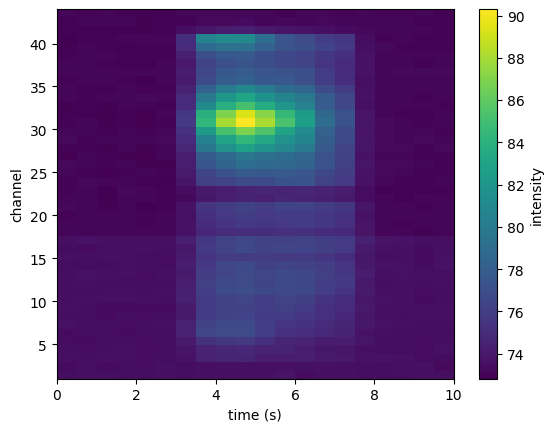

In [10]:
s.plot_band_map([433,433.5])

In [11]:
# Scale the intensity from thosands to ~1 for better fitting
s.set_scale(0.0001837) 
s.set_dark(frame=18)
s.set_baseline_zero(True)
s.set_time_linspace(0,10)

In [12]:
model = BHModel()

,Parameter,Value
0,C,0.37 ± 0.01
1,T_rot,2600 ± 100 K
2,dx,0.0106 ± 0.0003 nm
3,w_inst,0.0158 ± 0.0007 nm
4,base,0.027 ± 0.001
5,I_R7,(1.0 ± 1.4)e-4
6,I_R8,(1.0 ± 1.4)e-4


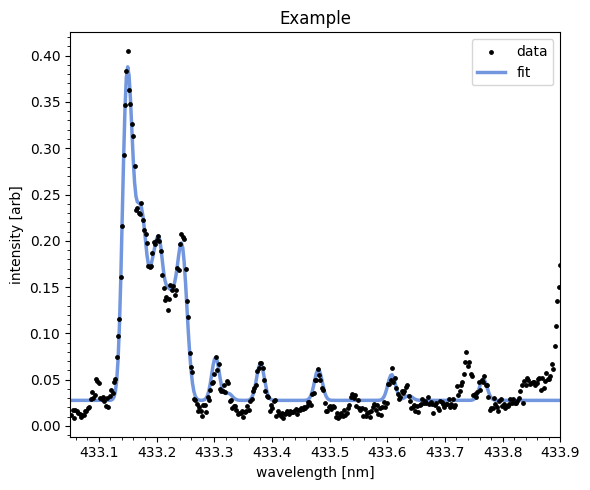

In [ ]:
fitr = BHFitter(s, model, warm_start=True, weight="none")

res = fitr.fit(frame=9, channel=31)
display(res["summary"])
_ = fitr.plot_single(res, title="Example")